## Import Library

In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

## Konfigurasi

In [4]:
DATA_DIR = '../data_clean'              
TEST_SIZE = 0.15                       
N_FOLDS = 5
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
RANDOM_SEED = 42
LEARNING_RATE = 0.00007

OUTPUT_DIR = '../results_kfold'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load DataSet

In [5]:
print("="*60)
print("LOADING DATA FROM data_clean")
print("="*60)

def load_images_from_folder(data_dir, img_size):
    images = []
    labels = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(class_path, fname)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(class_name)
    return np.array(images), np.array(labels)

X, y_str = load_images_from_folder(DATA_DIR, IMG_SIZE)
print(f"Total gambar : {len(X)}")
print(f"Dimensi      : {X.shape}")

# Encode label ke integer
le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"Kelas        : {le.classes_}  -> 0: Normal, 1: Tuberculosis")
print(f"Distribusi   : Normal={np.sum(y==0)}, TBC={np.sum(y==1)}")

LOADING DATA FROM data_clean
Total gambar : 10000
Dimensi      : (10000, 224, 224, 3)
Kelas        : ['Normal' 'Tuberculosis']  -> 0: Normal, 1: Tuberculosis
Distribusi   : Normal=5000, TBC=5000


## PISAHKAN TEST SET (HOLD-OUT)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
print(f"\nSplit data:")
print(f"  Train+Val : {len(X_temp)} gambar")
print(f"  Test      : {len(X_test)} gambar")


Split data:
  Train+Val : 8500 gambar
  Test      : 1500 gambar


## K-FOLD CROSS VALIDATION

In [7]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

fold_metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}
fold_histories = []
best_val_acc = 0
best_model_path = None

## Model MobileNetV2 

In [8]:
def build_model():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False
    
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(3e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(3e-4))(x)
    x = BatchNormalization()(x)
    out = Dense(2, activation='softmax', kernel_regularizer=l2(3e-4))(x)
    
    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, decay=1e-6, epsilon=1e-7, clipnorm=0.8),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
print("\n" + "="*60)
print("STARTING K-FOLD CROSS VALIDATION")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*50}")
    
    X_train_fold = X_temp[train_idx]
    y_train_fold = y_temp[train_idx]
    X_val_fold   = X_temp[val_idx]
    y_val_fold   = y_temp[val_idx]
    
    print(f"Train: {len(X_train_fold)} (Normal={np.sum(y_train_fold==0)}, TBC={np.sum(y_train_fold==1)})")
    print(f"Val  : {len(X_val_fold)} (Normal={np.sum(y_val_fold==0)}, TBC={np.sum(y_val_fold==1)})")
    
    # Class weight untuk menangani ketidakseimbangan (jika ada)
    cw = compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
    class_weight = {0: cw[0], 1: cw[1]}
    print(f"Class weight : Normal={cw[0]:.3f}, TBC={cw[1]:.3f}")
    
    # Augmentasi hanya pada training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.03,
        height_shift_range=0.03,
        zoom_range=[0.95, 1.05],
        horizontal_flip=True,
        fill_mode='constant',
        brightness_range=[0.98, 1.02]
    )
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    y_train_cat = tf.keras.utils.to_categorical(y_train_fold, 2)
    y_val_cat   = tf.keras.utils.to_categorical(y_val_fold, 2)
    
    train_gen = train_datagen.flow(X_train_fold, y_train_cat, batch_size=BATCH_SIZE, shuffle=True)
    val_gen   = val_datagen.flow(X_val_fold, y_val_cat, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model baru untuk setiap fold
    model = build_model()
    
    # Callbacks
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8),
        ModelCheckpoint(os.path.join(OUTPUT_DIR, f'best_model_fold_{fold+1}.h5'),
                        monitor='val_accuracy', save_best_only=True, mode='max')
    ]
    
    # Training
    history = model.fit(
        train_gen,
        steps_per_epoch=len(X_train_fold) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(X_val_fold) // BATCH_SIZE,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )
    fold_histories.append(history)
    
    # Evaluasi pada validation set fold ini
    y_pred_proba = model.predict(val_gen)
    y_pred = np.argmax(y_pred_proba, axis=1)
    acc  = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec  = recall_score(y_val_fold, y_pred)
    f1   = f1_score(y_val_fold, y_pred)
    
    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)
    
    print(f"\n📊 Validasi Fold {fold+1}:")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    
    # Simpan model terbaik secara keseluruhan (berdasarkan val_accuracy)
    if acc > best_val_acc:
        best_val_acc = acc
        best_model_path = os.path.join(OUTPUT_DIR, f'best_model_fold_{fold+1}.h5')
    
    # Plot history fold
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'Fold {fold+1} - Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'Fold {fold+1} - Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_fold_{fold+1}.png'))
    plt.close()
    
    # Simpan model final fold (opsional)
    model.save(os.path.join(OUTPUT_DIR, f'model_fold_{fold+1}_final.h5'))


STARTING K-FOLD CROSS VALIDATION

FOLD 1/5
Train: 6800 (Normal=3400, TBC=3400)
Val  : 1700 (Normal=850, TBC=850)
Class weight : Normal=1.000, TBC=1.000
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8403 - loss: 0.5347

212/212 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.9266 - loss: 0.3554 - val_accuracy: 0.8402 - val_loss: 0.5247 - learning_rate: 7.0000e-05
Epoch 2/20
  1/212 ━━━━━━━━━━━━━━━━━━━━ 2:47 793ms/step - accuracy: 0.9375 - loss: 0.3183

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


212/212 ━━━━━━━━━━━━━━━━━━━━ 36s 165ms/step - accuracy: 1.0000 - loss: 0.2039 - val_accuracy: 0.9835 - val_loss: 0.2564 - learning_rate: 7.0000e-05
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.9861 - loss: 0.2150 - val_accuracy: 0.9788 - val_loss: 0.2414 - learning_rate: 7.0000e-05
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 83s 387ms/step - accuracy: 1.0000 - loss: 0.1842 - val_accuracy: 0.9800 - val_loss: 0.2371 - learning_rate: 7.0000e-05
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9963 - loss: 0.1963

212/212 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9944 - loss: 0.1966 - val_accuracy: 0.9917 - val_loss: 0.2030 - learning_rate: 7.0000e-05
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 29s 133ms/step - accuracy: 1.0000 - loss: 0.1731 - val_accuracy: 0.9917 - val_loss: 0.2039 - learning_rate: 7.0000e-05
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9947 - loss: 0.1838 - val_accuracy: 0.9794 - val_loss: 0.2204 - learning_rate: 7.0000e-05
Epoch 8/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 27s 125ms/step - accuracy: 1.0000 - loss: 0.1852 - val_accuracy: 0.9794 - val_loss: 0.2204 - learning_rate: 2.1000e-05
Epoch 9/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9957 - loss: 0.1809

212/212 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.9959 - loss: 0.1803 - val_accuracy: 0.9971 - val_loss: 0.1753 - learning_rate: 2.1000e-05
Epoch 10/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 29s 135ms/step - accuracy: 1.0000 - loss: 0.1680 - val_accuracy: 0.9971 - val_loss: 0.1752 - learning_rate: 2.1000e-05
Epoch 11/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9952 - loss: 0.1815

212/212 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9966 - loss: 0.1774 - val_accuracy: 0.9988 - val_loss: 0.1687 - learning_rate: 2.1000e-05
Epoch 12/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - accuracy: 1.0000 - loss: 0.1715 - val_accuracy: 0.9988 - val_loss: 0.1687 - learning_rate: 2.1000e-05
Epoch 13/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9975 - loss: 0.1741 - val_accuracy: 0.9988 - val_loss: 0.1666 - learning_rate: 2.1000e-05
Epoch 14/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - accuracy: 0.8750 - loss: 0.2988 - val_accuracy: 0.9988 - val_loss: 0.1666 - learning_rate: 2.1000e-05
Epoch 15/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9975 - loss: 0.1722 - val_accuracy: 0.9988 - val_loss: 0.1681 - learning_rate: 2.1000e-05
Epoch 16/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - accuracy: 1.0000 - loss: 0.1655 - val_accuracy: 0.9988 - val_loss: 0.1681 - learning_rate: 6.3000e-06
Epoch 17/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - ac

## RINGKASAN K-FOLD

In [10]:
print("\n" + "="*60)
print("RINGKASAN 5-FOLD CROSS VALIDATION")
print("="*60)
summary_df = pd.DataFrame({
    'Fold': range(1, N_FOLDS+1),
    'Accuracy': fold_metrics['accuracy'],
    'Precision': fold_metrics['precision'],
    'Recall': fold_metrics['recall'],
    'F1': fold_metrics['f1']
})
print(summary_df.to_string(index=False))

print("\n📊 Rata-rata ± Std:")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean_val = np.mean(fold_metrics[metric])
    std_val = np.std(fold_metrics[metric])
    print(f"   {metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

summary_df.to_csv(os.path.join(OUTPUT_DIR, 'kfold_metrics.csv'), index=False)


RINGKASAN 5-FOLD CROSS VALIDATION
 Fold  Accuracy  Precision   Recall       F1
    1  0.997647        1.0 0.995294 0.997642
    2  0.997647        1.0 0.995294 0.997642
    3  1.000000        1.0 1.000000 1.000000
    4  0.994706        1.0 0.989412 0.994678
    5  0.995882        1.0 0.991765 0.995865

📊 Rata-rata ± Std:
   Accuracy  : 0.9972 ± 0.0018
   Precision : 1.0000 ± 0.0000
   Recall    : 0.9944 ± 0.0036
   F1        : 0.9972 ± 0.0018


## EVALUASI PADA TEST SET DENGAN MODEL TERBAIK


EVALUASI PADA TEST SET (HOLD-OUT)


47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 584ms/step

📊 Hasil Test Set:
   Accuracy  : 0.9993
   Precision : 1.0000
   Recall    : 0.9987
   F1-Score  : 0.9993


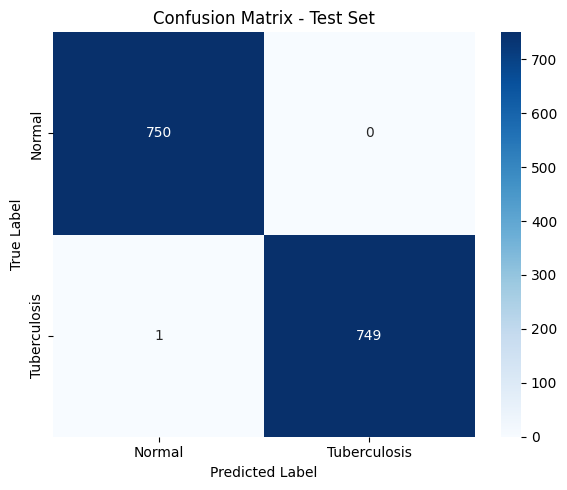


📋 Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       750
Tuberculosis       1.00      1.00      1.00       750

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [11]:
print("\n" + "="*60)
print("EVALUASI PADA TEST SET (HOLD-OUT)")
print("="*60)

# Load model terbaik dari cross validation
best_model = tf.keras.models.load_model(best_model_path)

# Preprocess test set
test_datagen = ImageDataGenerator(rescale=1./255)
y_test_cat = tf.keras.utils.to_categorical(y_test, 2)
test_gen = test_datagen.flow(X_test, y_test_cat, batch_size=BATCH_SIZE, shuffle=False)

# Prediksi
y_pred_proba = best_model.predict(test_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

# Metrik test
test_acc  = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred)

print(f"\n📊 Hasil Test Set:")
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   Precision : {test_prec:.4f}")
print(f"   Recall    : {test_rec:.4f}")
print(f"   F1-Score  : {test_f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'test_confusion_matrix.png'))
plt.show()

# Classification report
print("\n📋 Classification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))


## SIMPAN HASIL AKHIR

In [12]:
results = {
    'fold_metrics': fold_metrics,
    'test_metrics': {
        'accuracy': test_acc,
        'precision': test_prec,
        'recall': test_rec,
        'f1': test_f1
    },
    'best_model_path': best_model_path
}

import pickle
with open(os.path.join(OUTPUT_DIR, 'all_results.pkl'), 'wb') as f:
    pickle.dump(results, f)

print(f"\n✅ Semua hasil disimpan di: {OUTPUT_DIR}")
print(f"   - Model terbaik: {best_model_path}")
print("   - best_model_fold_*.h5 : model terbaik per fold")
print("   - model_fold_*_final.h5 : model akhir per fold")
print("   - history_fold_*.png    : grafik training per fold")
print("   - kfold_metrics.csv     : metrik per fold")
print("   - test_confusion_matrix.png : confusion matrix test")
print("   - all_results.pkl       : semua metrik disimpan")


✅ Semua hasil disimpan di: ../results_kfold
   - Model terbaik: ../results_kfold\best_model_fold_3.h5
   - best_model_fold_*.h5 : model terbaik per fold
   - model_fold_*_final.h5 : model akhir per fold
   - history_fold_*.png    : grafik training per fold
   - kfold_metrics.csv     : metrik per fold
   - test_confusion_matrix.png : confusion matrix test
   - all_results.pkl       : semua metrik disimpan
